<a href="https://colab.research.google.com/github/crahulnaidu/recursive-self-improving-ai/blob/main/month_1/ai_month_1_day_7_mini_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#ml model selection using k fold cross validation

The model with the least validation error is of degree 3
The error is  0.2788188815926118


Text(0.5, 1.0, 'Best model (degree =3)')

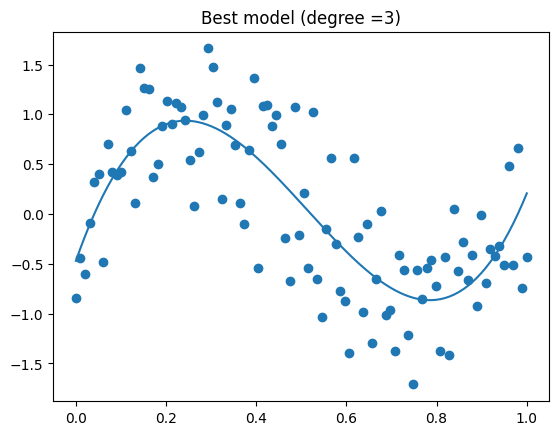

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold,train_test_split
from sklearn.linear_model import LinearRegression

X=np.linspace(0,1,100).reshape(-1,1)
y=np.sin(2*np.pi*X)+0.5*np.random.randn(100,1)

degree=[1,3,5,7,10,15]

kf=KFold(n_splits=5,shuffle=True)
cfold=[]

for deg in degree:
  poly=PolynomialFeatures(deg)
  X_poly=poly.fit_transform(X)

  val_error=[]

  for train_ind,val_ind in kf.split(X_poly):
    X_train,X_val=X_poly[train_ind],X_poly[val_ind]
    y_train,y_val=y[train_ind],y[val_ind]

    model=LinearRegression()
    model.fit(X_train,y_train)

    val_error.append(np.mean((model.predict(X_val)-y_val)**2))

  cfold.append(np.mean(val_error))


print(f"The model with the least validation error is of degree {degree[np.argmin(cfold)]}")
print("The error is ",cfold[np.argmin(cfold)])



model=LinearRegression()
best_degree=degree[np.argmin(cfold)]

poly=PolynomialFeatures(degree=best_degree)
X_poly=poly.fit_transform(X)

model.fit(X_poly,y)
X_test=np.linspace(0,1,200).reshape(-1,1)

X_test_poly=poly.fit_transform(X_test)
y_pred=model.predict(X_test_poly)

plt.scatter(X,y)
plt.plot(X_test,y_pred)
plt.title(f"Best model (degree ={best_degree})")







/tmp/ipykernel_1788/655945551.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


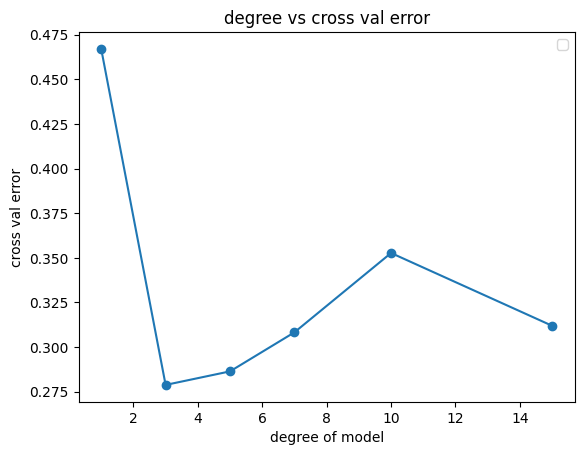

In [12]:
plt.plot(degree,cfold,marker='o')
plt.xlabel("degree of model")
plt.ylabel("cross val error")
plt.title("degree vs cross val error")
plt.legend()
plt.show()